In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Disease_symptom_and_patient_profile_dataset.csv to Disease_symptom_and_patient_profile_dataset.csv


In [ ]:
df = pd.read_csv("Disease_symptom_and_patient_profile_dataset.csv")

df.head()

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
4,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 349
Number of columns: 10


In [ ]:
print(df.columns)

Index(['Disease', 'Fever', 'Cough', 'Fatigue', 'Difficulty Breathing', 'Age',
       'Gender', 'Blood Pressure', 'Cholesterol Level', 'Outcome Variable'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Disease               349 non-null    object
 1   Fever                 349 non-null    object
 2   Cough                 349 non-null    object
 3   Fatigue               349 non-null    object
 4   Difficulty Breathing  349 non-null    object
 5   Age                   349 non-null    int64 
 6   Gender                349 non-null    object
 7   Blood Pressure        349 non-null    object
 8   Cholesterol Level     349 non-null    object
 9   Outcome Variable      349 non-null    object
dtypes: int64(1), object(9)
memory usage: 27.4+ KB


In [ ]:
df.isnull().sum()

,0
Disease,0
Fever,0
Cough,0
Fatigue,0
Difficulty Breathing,0
Age,0
Gender,0
Blood Pressure,0
Cholesterol Level,0
Outcome Variable,0


In [ ]:
df.duplicated().sum()

np.int64(49)

In [ ]:
print("Number of unique diseases:", df["Disease"].nunique())

Number of unique diseases: 116


In [ ]:
df["Disease"].value_counts()

,count
Disease,
Asthma,23
Stroke,16
Osteoporosis,14
Diabetes,10
Hypertension,10
...,...
Schizophrenia,1
Gout,1
Testicular Cancer,1


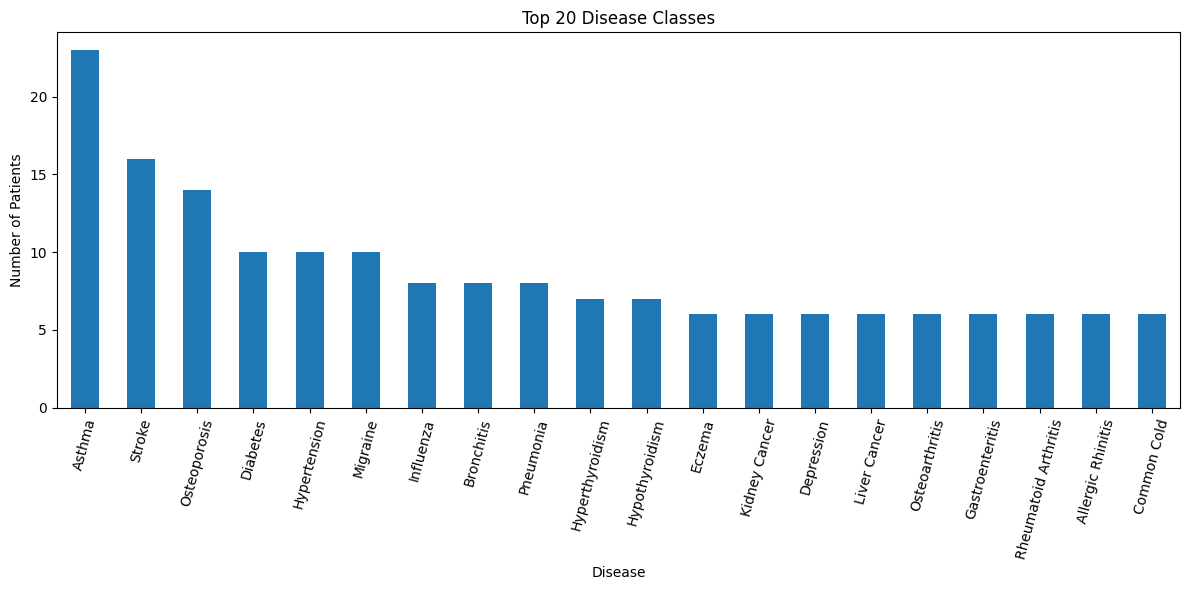

In [ ]:
plt.figure(figsize=(12, 6))

df["Disease"].value_counts().head(20).plot(kind="bar")

plt.title("Top 20 Disease Classes")
plt.xlabel("Disease")
plt.ylabel("Number of Patients")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

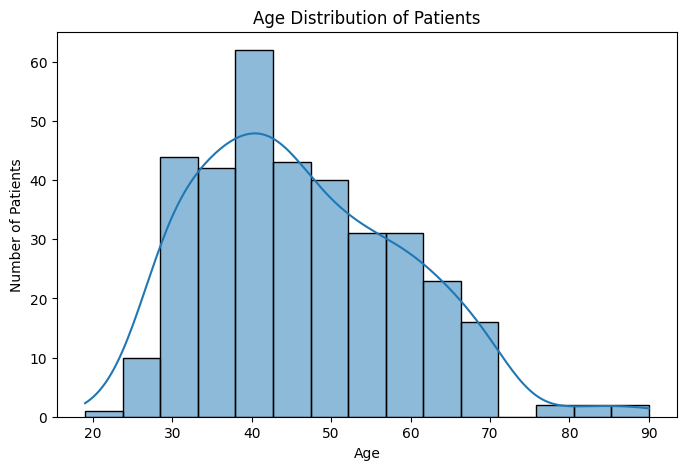

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"], bins=15, kde=True)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

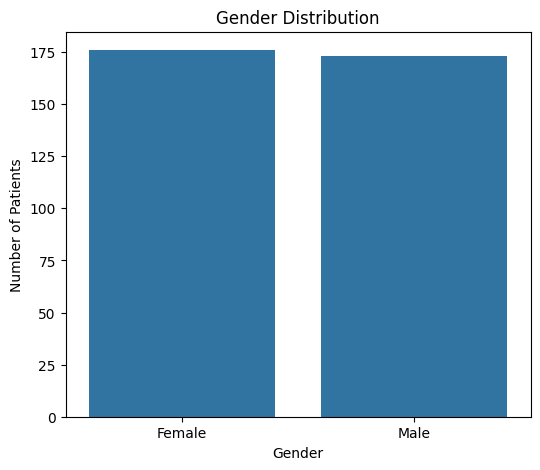

In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

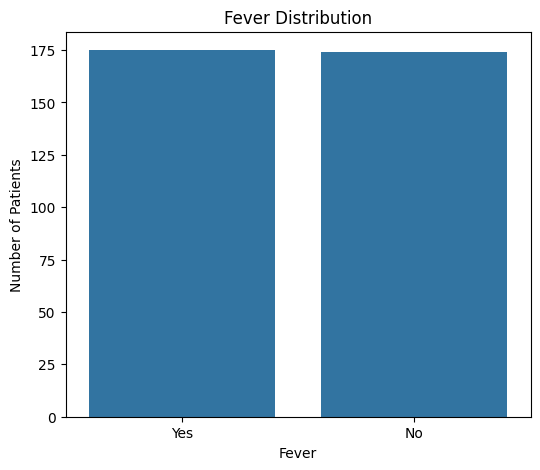

In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(x="Fever", data=df)

plt.title("Fever Distribution")
plt.xlabel("Fever")
plt.ylabel("Number of Patients")

plt.show()

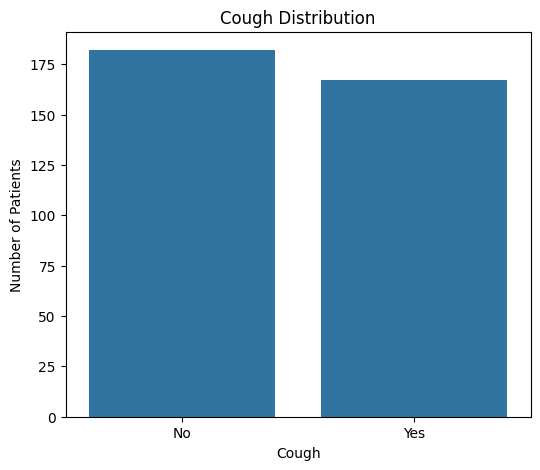

In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(x="Cough", data=df)

plt.title("Cough Distribution")
plt.xlabel("Cough")
plt.ylabel("Number of Patients")

plt.show()

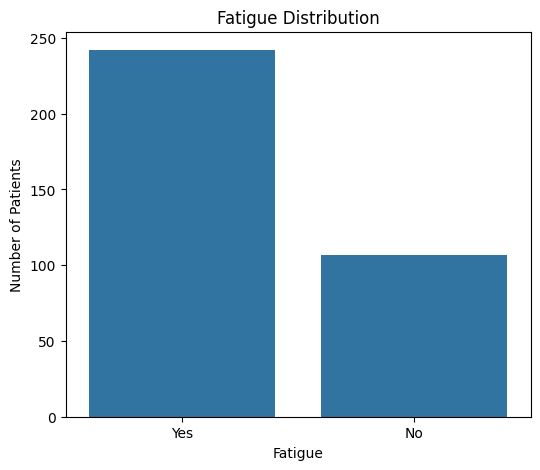

In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(x="Fatigue", data=df)

plt.title("Fatigue Distribution")
plt.xlabel("Fatigue")
plt.ylabel("Number of Patients")

plt.show()

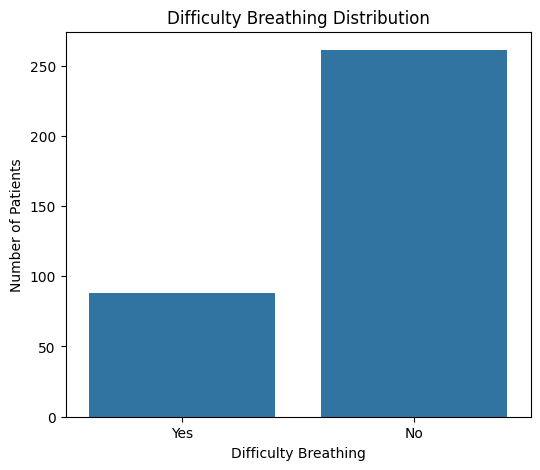

In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(x="Difficulty Breathing", data=df)

plt.title("Difficulty Breathing Distribution")
plt.xlabel("Difficulty Breathing")
plt.ylabel("Number of Patients")

plt.show()

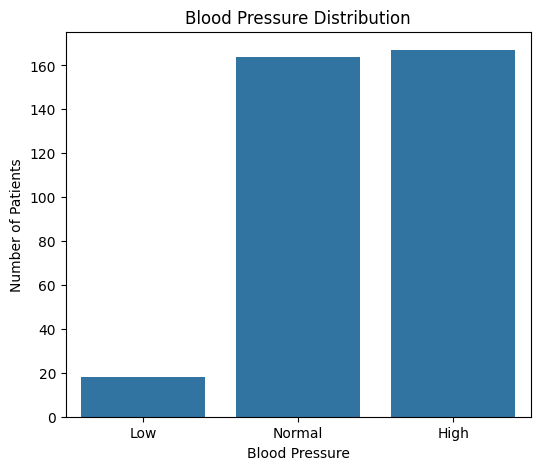

In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(x="Blood Pressure", data=df)

plt.title("Blood Pressure Distribution")
plt.xlabel("Blood Pressure")
plt.ylabel("Number of Patients")

plt.show()

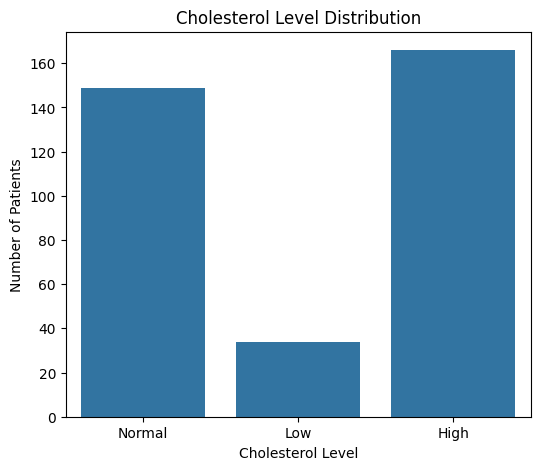

In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(x="Cholesterol Level", data=df)

plt.title("Cholesterol Level Distribution")
plt.xlabel("Cholesterol Level")
plt.ylabel("Number of Patients")

plt.show()

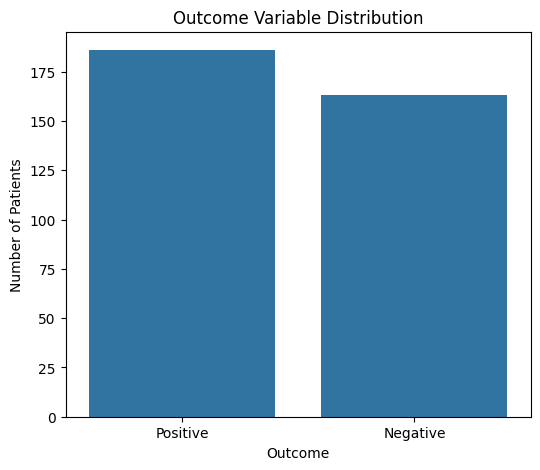

In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(x="Outcome Variable", data=df)

plt.title("Outcome Variable Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

In [ ]:
print("\n========== NUMERICAL SUMMARY ==========")
print(df.describe())

print("\n========== EDA COMPLETED ==========")


========== NUMERICAL SUMMARY ==========
              Age
count  349.000000
mean    46.323782
std     13.085090
min     19.000000
25%     35.000000
50%     45.000000
75%     55.000000
max     90.000000

========== EDA COMPLETED ==========


In [ ]:
# Create a copy of the dataset
data = df.copy()

# Remove duplicate records
data = data.drop_duplicates()

print("Original dataset shape:", df.shape)
print("After removing duplicates:", data.shape)

Original dataset shape: (349, 10)
After removing duplicates: (300, 10)


In [ ]:
# Remove Outcome Variable
data = data.drop("Outcome Variable", axis=1)

print("Remaining columns:")
print(data.columns.tolist())

Remaining columns:
['Disease', 'Fever', 'Cough', 'Fatigue', 'Difficulty Breathing', 'Age', 'Gender', 'Blood Pressure', 'Cholesterol Level']


In [ ]:
# Separate features and target

X = data.drop("Disease", axis=1)
y = data["Disease"]

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.name)

Features (X):
['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing', 'Age', 'Gender', 'Blood Pressure', 'Cholesterol Level']

Target (y):
Disease


In [ ]:
# Convert categorical features into numerical values

X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:")
print(X.columns.tolist())

print("\nFirst 5 rows:")
print(X.head())

Features after encoding:
['Age', 'Fever_Yes', 'Cough_Yes', 'Fatigue_Yes', 'Difficulty Breathing_Yes', 'Gender_Male', 'Blood Pressure_Low', 'Blood Pressure_Normal', 'Cholesterol Level_Low', 'Cholesterol Level_Normal']

First 5 rows:
   Age  Fever_Yes  Cough_Yes  Fatigue_Yes  Difficulty Breathing_Yes  \
0   19       True      False         True                      True   
1   25      False       True         True                     False   
2   25      False       True         True                     False   
3   25       True       True        False                      True   
5   25       True      False        False                     False   

   Gender_Male  Blood Pressure_Low  Blood Pressure_Normal  \
0        False                True                  False   
1        False               False                   True   
2        False               False                   True   
3         True               False                   True   
5        False               False  

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 10)
Testing data: (60, 10)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial"
)

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully!")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model training completed successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the Multinomial Logistic Regression model
model = LogisticRegression(
    max_iter=5000
)

# Train using scaled features
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# Make predictions on the test data
y_pred = model.predict(X_test_scaled)

print("First 10 actual diseases:")
print(y_test.iloc[:10].values)

print("\nFirst 10 predicted diseases:")
print(y_pred[:10])

First 10 actual diseases:
['Gastroenteritis' 'Diabetes' 'Pancreatitis' 'Anxiety Disorders'
 'Osteoporosis' 'Anxiety Disorders' 'Sleep Apnea' 'Asthma' 'Influenza'
 'Scoliosis']

First 10 predicted diseases:
['Pneumonia' 'Stroke' 'Liver Cancer' 'Eczema' 'Hemophilia' 'Hypertension'
 'Bronchitis' 'Asthma' 'Asthma' 'Hypertension']


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.06666666666666667
Model Accuracy (%): 6.666666666666667


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    zero_division=0
)

print(report)

                                              precision    recall  f1-score   support

                           Allergic Rhinitis       0.00      0.00      0.00         1
                           Anxiety Disorders       0.00      0.00      0.00         3
                                      Asthma       0.33      0.75      0.46         4
                                  Bronchitis       0.00      0.00      0.00         2
                      Chronic Kidney Disease       0.00      0.00      0.00         1
Chronic Obstructive Pulmonary Disease (COPD)       0.00      0.00      0.00         1
                                 Common Cold       0.00      0.00      0.00         1
                     Coronary Artery Disease       0.00      0.00      0.00         1
                             Crohn's Disease       0.00      0.00      0.00         1
                                  Depression       0.00      0.00      0.00         1
                                    Diabetes       0.

In [ ]:
disease_counts = data["Disease"].value_counts()

print(disease_counts)
print("Total diseases:", len(disease_counts))
print("\nDiseases with at least 5 samples:")
print(disease_counts[disease_counts >= 5])

Disease
Asthma               16
Osteoporosis         12
Stroke               11
Diabetes             10
Hypertension         10
                     ..
Schizophrenia         1
Gout                  1
Testicular Cancer     1
Tonsillitis           1
Williams Syndrome     1
Name: count, Length: 116, dtype: int64
Total diseases: 116

Diseases with at least 5 samples:
Disease
Asthma                     16
Osteoporosis               12
Stroke                     11
Diabetes                   10
Hypertension               10
Migraine                   10
Influenza                   7
Bronchitis                  7
Pneumonia                   7
Common Cold                 6
Eczema                      6
Allergic Rhinitis           6
Kidney Cancer               6
Liver Cancer                6
Anxiety Disorders           6
Osteoarthritis              6
Depression                  6
Rheumatoid Arthritis        6
Gastroenteritis             6
Pancreatitis                5
Liver Disease             

In [ ]:
# Select diseases with at least 5 records

disease_counts = data["Disease"].value_counts()

selected_diseases = disease_counts[disease_counts >= 5].index

filtered_data = data[data["Disease"].isin(selected_diseases)].copy()

print("Number of diseases selected:", filtered_data["Disease"].nunique())
print("Number of records:", len(filtered_data))

print("\nDisease distribution:")
print(filtered_data["Disease"].value_counts())

Number of diseases selected: 28
Number of records: 195

Disease distribution:
Disease
Asthma                     16
Osteoporosis               12
Stroke                     11
Diabetes                   10
Hypertension               10
Migraine                   10
Bronchitis                  7
Pneumonia                   7
Influenza                   7
Allergic Rhinitis           6
Eczema                      6
Common Cold                 6
Osteoarthritis              6
Anxiety Disorders           6
Rheumatoid Arthritis        6
Depression                  6
Gastroenteritis             6
Kidney Cancer               6
Liver Cancer                6
Hyperthyroidism             5
Pancreatitis                5
Urinary Tract Infection     5
Ulcerative Colitis          5
Psoriasis                   5
Liver Disease               5
Kidney Disease              5
Hypothyroidism              5
Crohn's Disease             5
Name: count, dtype: int64


In [ ]:
# Separate features and target from filtered data

X = filtered_data.drop("Disease", axis=1)
y = filtered_data["Disease"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nNumber of samples:", len(y))
print("Number of disease classes:", y.nunique())

Features:
['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing', 'Age', 'Gender', 'Blood Pressure', 'Cholesterol Level']

Target:
Disease

Number of samples: 195
Number of disease classes: 28


In [ ]:
# Convert categorical features into numerical values

X = pd.get_dummies(X, drop_first=True)

# Convert True/False to 1/0
X = X.astype(int)

print("Encoded features:")
print(X.columns.tolist())

print("\nFirst 5 rows:")
print(X.head())

Encoded features:
['Age', 'Fever_Yes', 'Cough_Yes', 'Fatigue_Yes', 'Difficulty Breathing_Yes', 'Gender_Male', 'Blood Pressure_Low', 'Blood Pressure_Normal', 'Cholesterol Level_Low', 'Cholesterol Level_Normal']

First 5 rows:
   Age  Fever_Yes  Cough_Yes  Fatigue_Yes  Difficulty Breathing_Yes  \
0   19          1          0            1                         1   
1   25          0          1            1                         0   
2   25          0          1            1                         0   
3   25          1          1            0                         1   
5   25          1          0            0                         0   

   Gender_Male  Blood Pressure_Low  Blood Pressure_Normal  \
0            0                   1                      0   
1            0                   0                      1   
2            0                   0                      1   
3            1                   0                      1   
5            0                   0         

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training features:", X_train.shape[1])
print("Testing features:", X_test.shape[1])

Training samples: 156
Testing samples: 39
Training features: 10
Testing features: 10


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the Multinomial Logistic Regression model
model = LogisticRegression(
    max_iter=5000
)

# Train the model
model.fit(X_train_scaled, y_train)

print("Improved model trained successfully!")

Improved model trained successfully!


In [ ]:
# Predict diseases for the test data

y_pred = model.predict(X_test_scaled)

print("First 10 actual diseases:")
print(y_test.iloc[:10].values)

print("\nFirst 10 predicted diseases:")
print(y_pred[:10])

First 10 actual diseases:
['Osteoarthritis' 'Urinary Tract Infection' 'Ulcerative Colitis'
 'Migraine' 'Diabetes' 'Eczema' 'Liver Cancer' 'Bronchitis' 'Hypertension'
 'Anxiety Disorders']

First 10 predicted diseases:
['Allergic Rhinitis' 'Rheumatoid Arthritis' 'Migraine' 'Hypertension'
 'Migraine' 'Osteoporosis' 'Asthma' 'Stroke' 'Hypertension' 'Asthma']


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Improved Model Accuracy:", accuracy)
print("Improved Model Accuracy (%):", round(accuracy * 100, 2))

Improved Model Accuracy: 0.07692307692307693
Improved Model Accuracy (%): 7.69


In [ ]:
from sklearn.metrics import classification_report

print("Classification Report")
print("=" * 70)

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Classification Report
                         precision    recall  f1-score   support

      Allergic Rhinitis       0.00      0.00      0.00         1
      Anxiety Disorders       0.00      0.00      0.00         1
                 Asthma       0.29      0.67      0.40         3
             Bronchitis       0.00      0.00      0.00         2
            Common Cold       0.00      0.00      0.00         1
        Crohn's Disease       0.00      0.00      0.00         1
             Depression       0.00      0.00      0.00         1
               Diabetes       0.00      0.00      0.00         2
                 Eczema       0.00      0.00      0.00         1
        Gastroenteritis       0.00      0.00      0.00         1
           Hypertension       0.20      0.50      0.29         2
        Hyperthyroidism       0.00      0.00      0.00         1
         Hypothyroidism       0.00      0.00      0.00         1
              Influenza       0.00      0.00      0.00         2
  

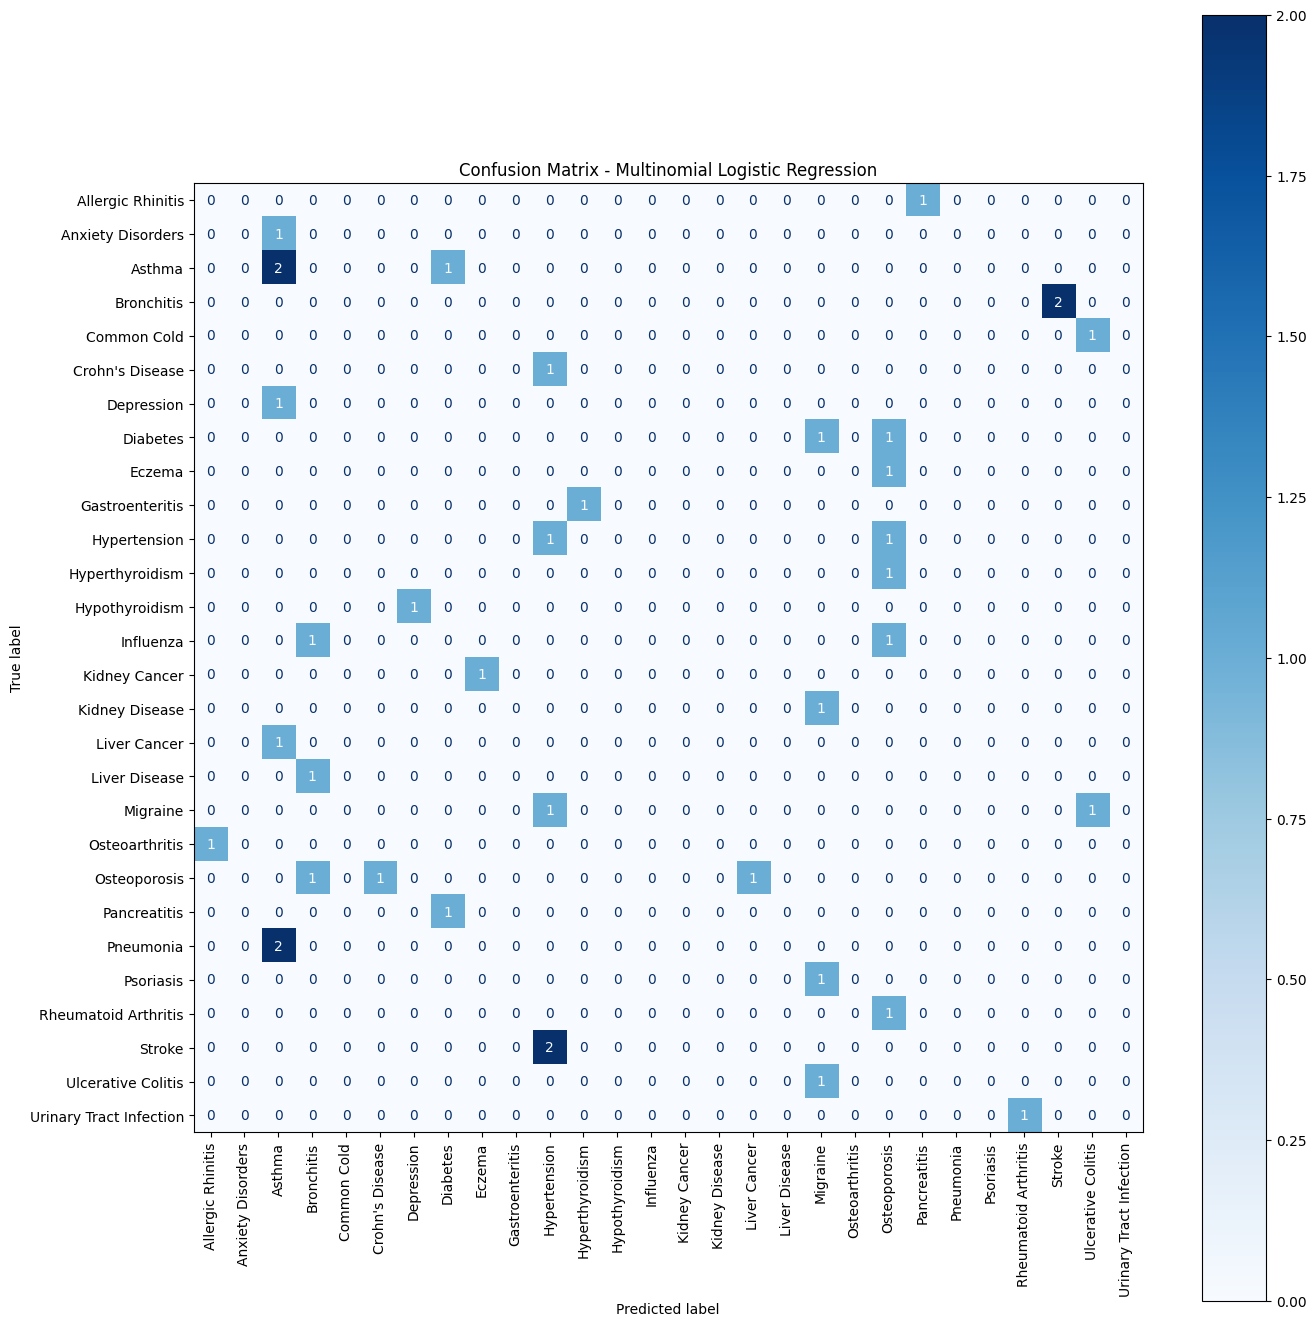

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(14, 14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(
    xticks_rotation=90,
    cmap="Blues",
    ax=plt.gca()
)

plt.title("Confusion Matrix - Multinomial Logistic Regression")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [ ]:
# Make predictions using Decision Tree

dt_pred = dt_model.predict(X_test)

print("First 10 actual diseases:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Decision Tree predictions:")
print(dt_pred[:10])

First 10 actual diseases:
['Osteoarthritis' 'Urinary Tract Infection' 'Ulcerative Colitis'
 'Migraine' 'Diabetes' 'Eczema' 'Liver Cancer' 'Bronchitis' 'Hypertension'
 'Anxiety Disorders']

First 10 Decision Tree predictions:
['Allergic Rhinitis' 'Asthma' 'Migraine' 'Allergic Rhinitis' 'Migraine'
 "Crohn's Disease" 'Rheumatoid Arthritis' 'Common Cold' "Crohn's Disease"
 'Common Cold']


In [ ]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Accuracy (%):", round(dt_accuracy * 100, 2))

Decision Tree Accuracy: 0.05128205128205128
Decision Tree Accuracy (%): 5.13


In [ ]:
# Compare the two models

results = pd.DataFrame({
    "Model": [
        "Multinomial Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy (%)": [
        round(accuracy * 100, 2),
        round(dt_accuracy * 100, 2)
    ]
})

print(results)

                             Model  Accuracy (%)
0  Multinomial Logistic Regression          7.69
1                    Decision Tree          5.13
